
# Анализ временного ряда: ежемесячное количество запусков космических ракет

**Содержание:**
1. Импорт библиотек и настройка  
2. Загрузка данных  
3. Первичный обзор и очистка  
4. Создание временного ряда (агрегация)  
5. Базовый анализ и обработка пропусков  
6. EDA: визуализация  
7. Исследование сезонности и тренда  
8. Декомпозиция ряда  
9. Автокорреляционный анализ  
10. Постановка задачи прогнозирования  
11. Сохранение подготовленных данных  


## 1. Импорт библиотек и настройка окружения


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="statsmodels")
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_style('whitegrid')
sns.set(rc={'figure.figsize':(12, 5)})
np.random.seed(42)
import os

# папка для результатов
os.makedirs('results', exist_ok=True)


Загрузка данных и очистка

In [5]:
url = 'https://raw.githubusercontent.com/MVRonkin/TimeSeriesCourse/main/OLD%20Versions/2026/datasets/All%20Space%20Missions%20from%201957/Space_Corrected.csv'
df = pd.read_csv(url)

df.columns = df.columns.str.strip()
df = df.rename(columns={
    'Unnamed: 0': 'id',
    'Company Name': 'company',
    'Status Rocket': 'rocket_status',
    'Rocket': 'cost_millions',
    'Status Mission': 'mission_status'
})

def parse_mixed_date(date_str):
    date_str = str(date_str).strip()
    if ' UTC' in date_str:
        date_str = date_str.replace(' UTC', '')
        return pd.to_datetime(date_str, format='%a %b %d, %Y %H:%M')
    else:
        return pd.to_datetime(date_str, format='%a %b %d, %Y')

df['Datum'] = df['Datum'].apply(parse_mixed_date)

df = df.dropna(subset=['Datum'])

print(f'Форма после очистки: {df.shape}')
df[['company', 'Datum', 'rocket_status', 'mission_status']].head(3)

print("Типы данных:")
print(df.dtypes)
print("\nПропуски:")
print(df.isna().sum())



print(f'Пропусков в дате: {df["Datum"].isna().sum()}')
df = df.dropna(subset=['Datum'])
df['Datum'] = pd.to_datetime(df['Datum'], utc=True).dt.tz_convert(None)




Форма после очистки: (4324, 9)
Типы данных:
Unnamed: 0.1               int64
id                         int64
company                   object
Location                  object
Datum             datetime64[ns]
Detail                    object
rocket_status             object
cost_millions             object
mission_status            object
dtype: object

Пропуски:
Unnamed: 0.1         0
id                   0
company              0
Location             0
Datum                0
Detail               0
rocket_status        0
cost_millions     3360
mission_status       0
dtype: int64
Пропусков в дате: 0


Создание целевого временного ряда

In [6]:

# Устанавливаем дату как индекс
df.set_index('Datum', inplace=True)
df = df.sort_index()

monthly_launches = df.resample('MS').size()
monthly_launches.name = 'launches'

print(f'Форма ряда: {monthly_launches.shape}')
print(f'Диапазон дат: с {monthly_launches.index.min().date()} по {monthly_launches.index.max().date()}')
monthly_launches.head(10)


Форма ряда: (755,)
Диапазон дат: с 1957-10-01 по 2020-08-01


,launches
Datum,
1957-10-01,1
1957-11-01,1
1957-12-01,1
1958-01-01,0
1958-02-01,2
1958-03-01,3
1958-04-01,2
1958-05-01,2
1958-06-01,1


Базовый анализ

In [7]:

# Проверяем непрерывность индекса
full_range = pd.date_range(start=monthly_launches.index.min(),
                           end=monthly_launches.index.max(),
                           freq='MS')
missing_months = full_range.difference(monthly_launches.index)
print(f'Пропущено месяцев: {len(missing_months)}')
if len(missing_months) > 0:
    print('Примеры пропущенных месяцев:', missing_months[:5].tolist())

monthly_launches = monthly_launches.reindex(full_range, fill_value=0)
monthly_launches.index.freq = 'MS'



print("Базовая статистика:")
print(monthly_launches.describe())
print(f"\nКоличество нулевых месяцев: {(monthly_launches == 0).sum()}")


print(f"Монотонность индекса: {monthly_launches.index.is_monotonic_increasing}")
print(f"Дубликаты индекса: {monthly_launches.index.has_duplicates}")


Пропущено месяцев: 0
Базовая статистика:
count    755.000000
mean       5.727152
std        3.109367
min        0.000000
25%        4.000000
50%        5.000000
75%        8.000000
max       18.000000
Name: launches, dtype: float64

Количество нулевых месяцев: 8
Монотонность индекса: True
Дубликаты индекса: False


EDA

Линейный график с scikit-ma (plotly)

In [8]:

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=monthly_launches.index,
    y=monthly_launches.values,
    mode='lines+markers',
    name='Количество запусков',
    line=dict(width=1)
))
fig.update_layout(
    title='Ежемесячное количество космических запусков',
    xaxis_title='Дата',
    yaxis_title='Запусков в месяц',
    height=500
)
fig.write_html('results/monthly_launches_interactive.html')
print('Интерактивный график сохранён в results/monthly_launches_interactive.html')
fig.show()



Интерактивный график сохранён в results/monthly_launches_interactive.html


Скользящее среднее для сглаживания (12 месяцев)

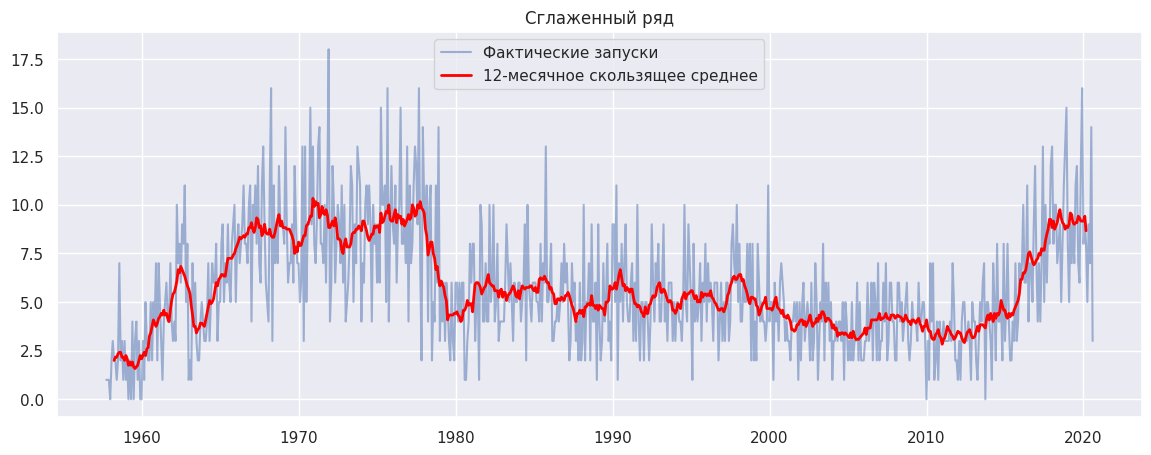

In [9]:

monthly_launches_rolling = monthly_launches.rolling(window=12, center=True).mean()

plt.figure(figsize=(14,5))
plt.plot(monthly_launches.index, monthly_launches.values,
         alpha=0.5, label='Фактические запуски')
plt.plot(monthly_launches_rolling.index, monthly_launches_rolling.values,
         color='red', linewidth=2, label='12-месячное скользящее среднее')
plt.title('Сглаженный ряд')
plt.legend()
plt.savefig('results/1.png', dpi=150, bbox_inches='tight')
plt.show()


Boxplot по месяцам - сезонность

/tmp/ipykernel_15783/3180217547.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




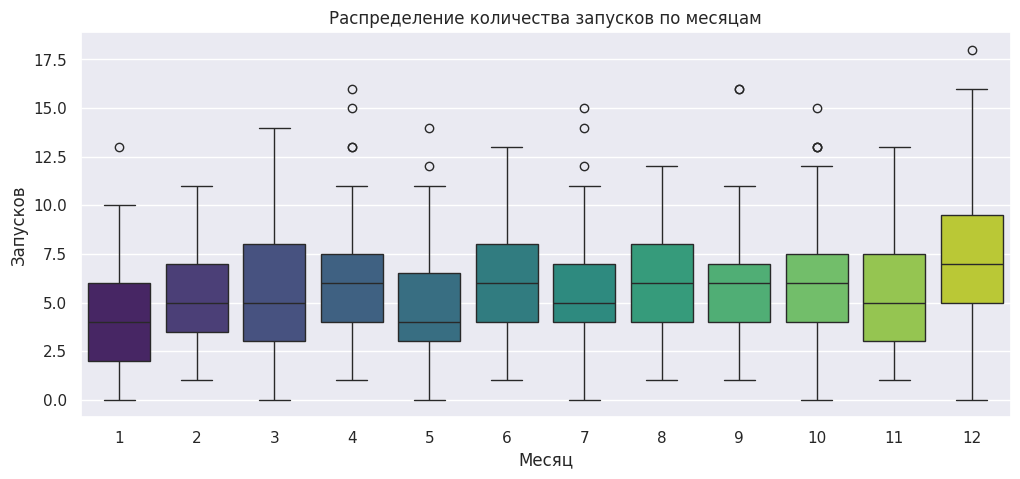

In [10]:

df_box = monthly_launches.copy()
df_box = df_box.to_frame()
df_box['month'] = df_box.index.month

plt.figure(figsize=(12,5))
sns.boxplot(x='month', y='launches', data=df_box, palette='viridis')
plt.title('Распределение количества запусков по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Запусков')
plt.savefig('results/2.png', dpi=150, bbox_inches='tight')
plt.show()


Boxplot по годам (для выявления тренда)

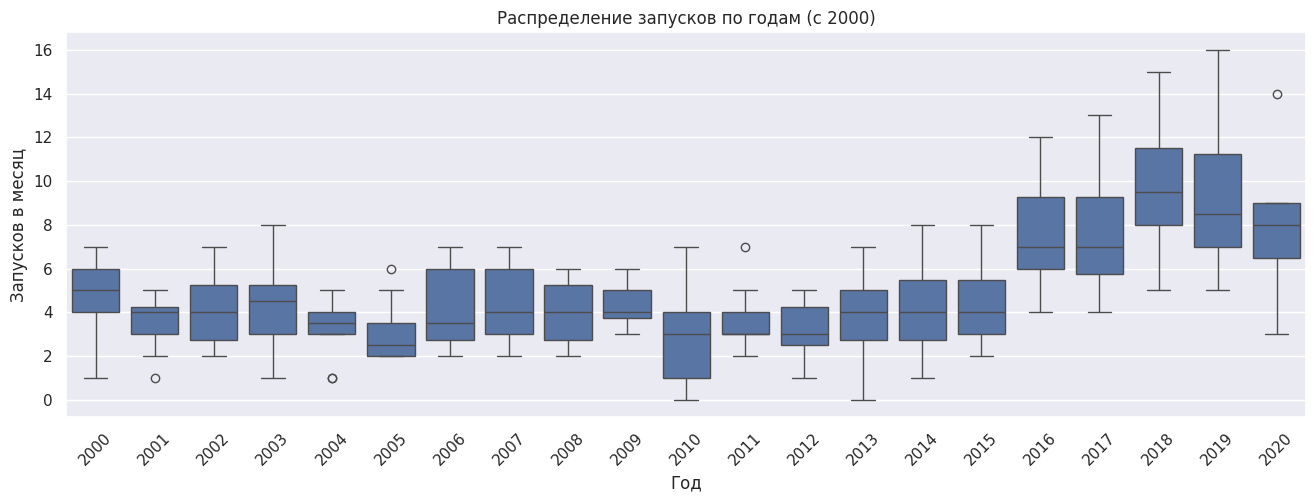

In [11]:

df_box['year'] = df_box.index.year
plt.figure(figsize=(16,5))
sns.boxplot(x='year', y='launches', data=df_box[df_box['year'] >= 2000])
plt.xticks(rotation=45)
plt.title('Распределение запусков по годам (с 2000)')
plt.xlabel('Год')
plt.ylabel('Запусков в месяц')
plt.savefig('results/3.png', dpi=150, bbox_inches='tight')
plt.show()


Анализ тренда и сезонности

Визуальная оценка тренда через годовое агрегирование

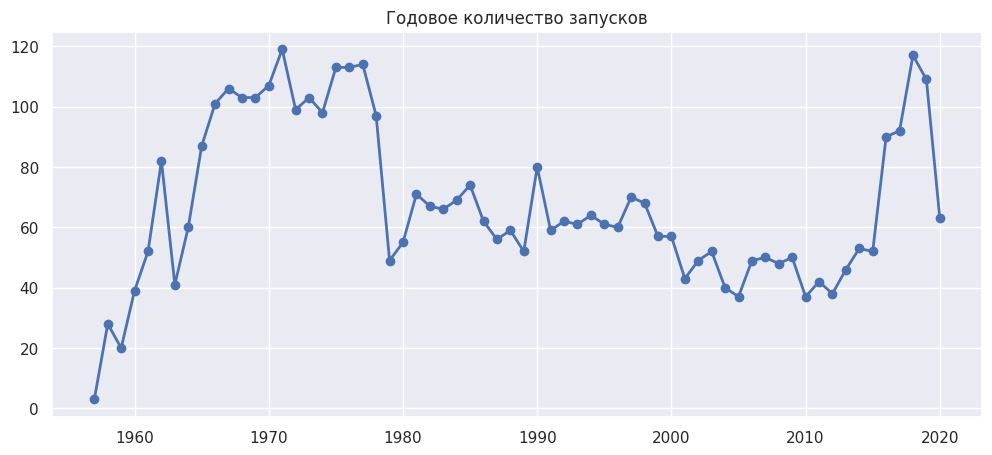

In [12]:

annual_launches = monthly_launches.resample('YS').sum()  # YS – начало года
plt.figure(figsize=(12,5))
plt.plot(annual_launches.index, annual_launches.values,
         marker='o', linestyle='-', linewidth=2)
plt.title('Годовое количество запусков')
plt.grid(True)
plt.savefig('results/4.png', dpi=150, bbox_inches='tight')
plt.show()



Декомпозиция ряда (аддитивная модель)

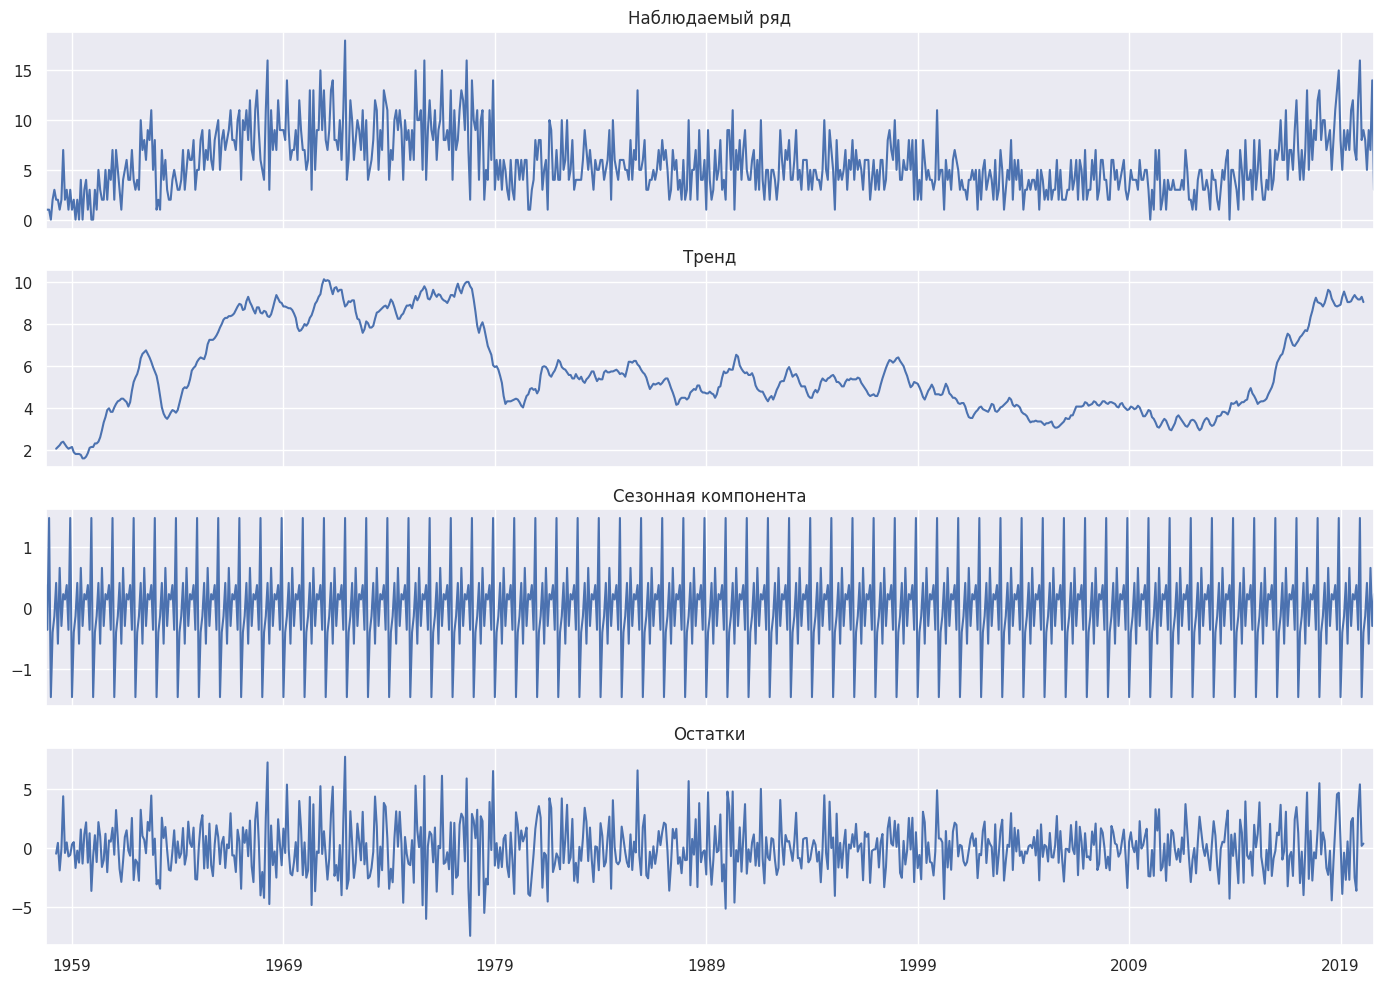

In [13]:

decomp = seasonal_decompose(monthly_launches, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title='Наблюдаемый ряд')
decomp.trend.plot(ax=axes[1], title='Тренд')
decomp.seasonal.plot(ax=axes[2], title='Сезонная компонента')
decomp.resid.plot(ax=axes[3], title='Остатки')
plt.tight_layout()
plt.savefig('results/5.png', dpi=150, bbox_inches='tight')
plt.show()


ACF/PACF

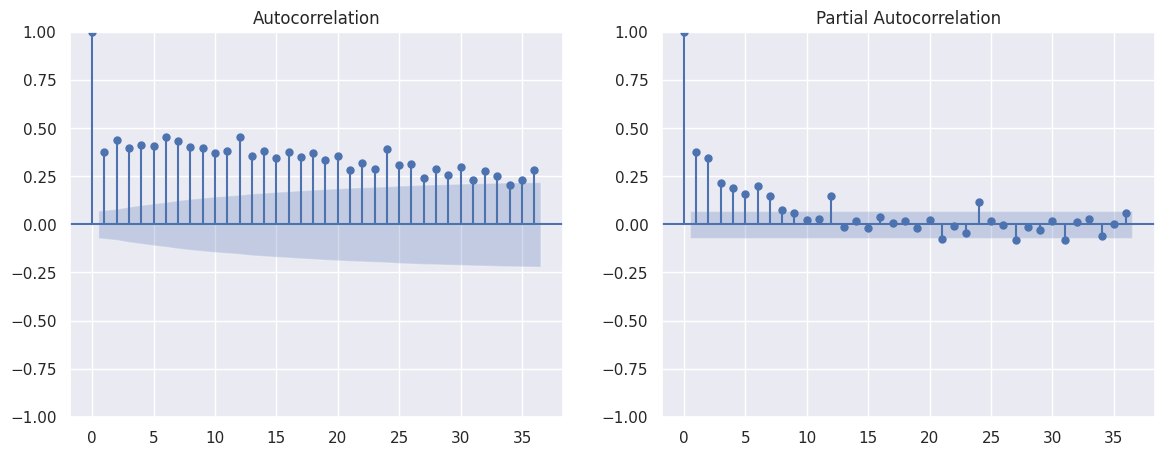

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(14,5))
plot_acf(monthly_launches.dropna(), lags=36, ax=axes[0])
plot_pacf(monthly_launches.dropna(), lags=36, ax=axes[1], method='ywm')
plt.savefig('results/6.png', dpi=150, bbox_inches='tight')
plt.show()


вклад компаний

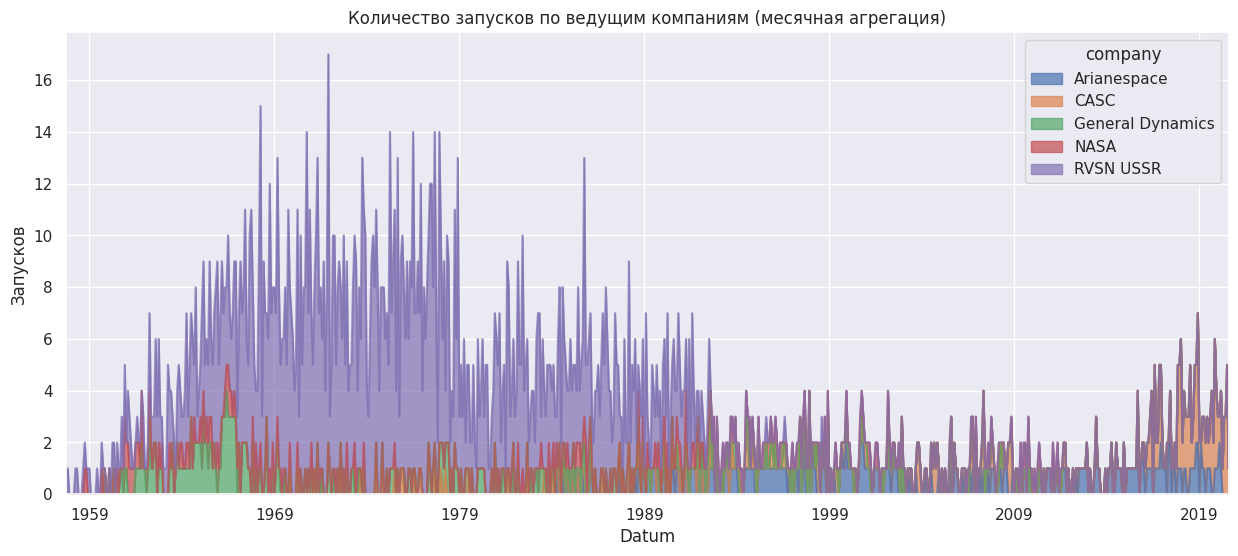

In [15]:

top_companies = df['company'].value_counts().nlargest(5).index
df_top = df[df['company'].isin(top_companies)]

company_monthly = df_top.groupby('company').resample('MS').size().unstack(level=0, fill_value=0)

company_monthly.plot.area(figsize=(15,6), alpha=0.7)
plt.title('Количество запусков по ведущим компаниям (месячная агрегация)')
plt.ylabel('Запусков')
plt.savefig('results/7.png', dpi=150, bbox_inches='tight')
plt.show()




Сохранение подготовленного ряда для дальнейшего использования

In [16]:

monthly_launches.to_csv('results/monthly_launches.csv', header=True)
print("Ряд monthly_launches сохранён в results/monthly_launches.csv")


Ряд monthly_launches сохранён в results/monthly_launches.csv
